In [26]:
#Paper Research: https://www.nature.com/articles/s41586-023-06096-3

In [27]:
# Transverse Field Ising Model to Demo Primitives

from qiskit import QuantumCircuit
import numpy as np
from qiskit.circuit.library import YGate

# Manually create the SQRT(Y) and SQRT(Y) dagger gates
SYGate = YGate().power(0.5)
SYGate.name = "SY"

SYdgGate = YGate().power(-0.5)
SYdgGate.name = "SY†"

def generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits=0, trotter_barriers = False, layer_barriers = False):
    if num_cl_bits == 0:
        qc = QuantumCircuit(num_qubits)
    else:
        qc = QuantumCircuit(num_qubits, num_cl_bits)
        
    qc = QuantumCircuit(num_qubits, num_cl_bits)
    
    for trotter_step in range(num_trotter_steps):
        add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()

    return qc

def add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers = False):
    # Adding the Rzz gates between even layers
    for i in range(0, qc.num_qubits - 1, 2):
        qc.sdg([i, i+1])
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
    if layer_barriers:
        qc.barrier()
        
    # Adding the Rzz gates between odd layers
    for i in range(1, qc.num_qubits - 1, 2):  # Note: changed 0 to 1 for odd layers!
        qc.sdg([i, i+1])
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
    if layer_barriers:
        qc.barrier()
        
    qc.rx(rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()

In [28]:
num_qubits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, trotter_barriers = True, layer_barriers = True)
fig = qc.draw(output='mpl')
fig.savefig("my_circuit.png")

In [29]:
#Demo Sampler

def append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barriers = False, layer_barriers = False):
    qc = QuantumCircuit(num_qubits)
    
    for trotter_step in range(num_trotter_steps):
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()

def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers = False):
    qc.rx(-rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()
   # Adding the Rzz gates between odd layers
    for i in range(1, qc.num_qubits - 1, 2):  # Note: changed 0 to 1 for odd layers!
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
        qc.s([i, i+1])
    if layer_barriers:
        qc.barrier()
    # Adding the Rzz gates between odd layers
    for i in range(0, qc.num_qubits - 1, 2):  # Note: changed 0 to 1 for odd layers!
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
        qc.s([i, i+1])
    if layer_barriers:
        qc.barrier()

In [30]:
append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barriers = True, layer_barriers = True)

fig = qc.draw(output='mpl', fold=-1)
fig.savefig("my_circuit_mirrored.png")

In [31]:
# Map problem to circuits and observables

max_trotter_steps = 10
num_qubits = 10
measured_qubits = [4, 5]

qc_list=[]
for trottered_steps in range(max_trotter_steps):
    qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits=len(measured_qubits), trotter_barriers = True, layer_barriers = True)
    append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barriers = True, layer_barriers = True)
    qc.measure(measured_qubits, list(range(len(measured_qubits))))
    qc_list.append(qc)
    

In [32]:
#Step 2: Optimize

from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = "ibm_kingston"
service = QiskitRuntimeService()
backend = service.backend(backend_name)

qc_transpiled_list = transpile(qc_list, backend=backend)

In [37]:
# Step 3: Execute on hardware
from qiskit_ibm_runtime import SamplerV2 as Sampler

# FIX 1: Pass the backend positionally, NOT as a keyword argument
sampler = Sampler(backend) 

# FIX 2: Remove the direct boolean assignment to dynamical_decoupling
# Just defining the sequence_type automatically turns it on
sampler.options.dynamical_decoupling.sequence_type = "XY4"

# Note: Make sure qc_transpiled_list is a list of Pubs (Primitive Unified Blocs)
# Usually formatted as: [(circuit,)] or [(circuit, theta_values)]
job = sampler.run(qc_transpiled_list)
print(f"Job ID: {job.job_id()}")

Job ID: d8g226bo3njc73f12p1g


In [38]:
#Step 4: Post-Processing and plotting

job_id = "d8g226bo3njc73f12p1g"
job = service.job(job_id)

survival_probability_list = []
for trotter_step in range(max_trotter_steps):
    try:
        data = job.result()[trotter_step].data
        survival_probability_list.append(data.c.get_counts()['0' * len(measured_qubits)] / data.c_num_shots)
    except:
        survival_probability_list.append(0)

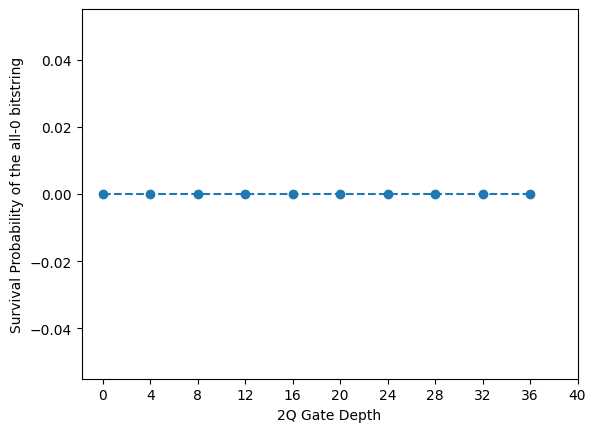

In [41]:
import matplotlib.pyplot as plt

plt.plot(list(range(0, 4 * max_trotter_steps, 4)), survival_probability_list, '--o')
plt.xlabel("2Q Gate Depth")
plt.ylabel("Survival Probability of the all-0 bitstring")
plt.xticks(np.arange(0, 44, 4))
plt.show()

In [44]:
#Estimator

#Step 1: Map problem

from qiskit.circuit import Parameter

rx_angle = Parameter("rx_angle")
trotter_steps = 2
qc = generate_1d_tfim_circuit(num_qubits, trotter_steps, rx_angle)

from qiskit.quantum_info import SparsePauliOp

middle_index = num_qubits // 2
observable = SparsePauliOp("I" * middle_index + "Z" + "I" * (middle_index - 1))

In [45]:
#Step 2: Optimize

from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService
backend = "ibm_kingston"
service = QiskitRuntimeService()
backend = service.backend(backend)

qc_transpiled = transpile(qc, backend=backend)

observable = observable.apply_layout(qc_transpiled.layout)

In [46]:
#Step 3: Execute On Quantum Hardware

from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions

min_rx_angle = 0
max_rx_angle = np.pi/2
num_rx_angles = 12
trotter_steps = 2
rx_angles_list = np.linspace(min_rx_angle, max_rx_angle, num_rx_angles)

options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

estimator = EstimatorV2(backend, options=options)

job = estimator.run([(qc_transpiled, observable, rx_angles_list)])
print(f"Job ID: {job.job_id()}")

Job ID: d8g2al9vjngc73aql420


(-0.01, 1.1)

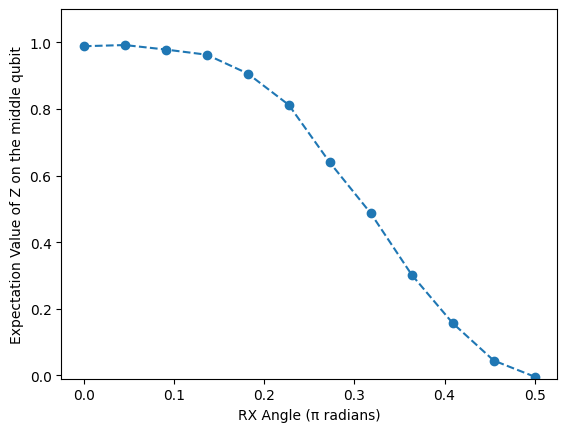

In [47]:
#Step 4: Post-Processing and plotting

job_id = "d8g2al9vjngc73aql420"
job = service.job(job_id)

exp_val_list = job.result()[0].data.evs

plt.plot(rx_angles_list/np.pi, exp_val_list, '--o')
plt.xlabel("RX Angle (π radians)")
plt.ylabel("Expectation Value of Z on the middle qubit")
plt.ylim(-.01, 1.1)
